# Domain Shift Diagnostic (Domain AUC)

This notebook measures feature-space domain shift between:
- Motor 1: data_set_4
- Motor 2: data_set_6

Method summary:
1. Build vibration features for both motors using the same pipeline settings as vibro_model.ipynb.
2. Train a domain classifier on concatenated features (0 = Motor 1, 1 = Motor 2).
3. Report holdout ROC AUC, accuracy, confusion matrix, and ROC curve.

In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Add project root for local imports
project_root = Path(__file__).parent.parent.parent if "__file__" in globals() else Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from ml_toolbox.data_loader import (
    DataLoader,
    FeatureConfig,
    create_windows_for_ml,
    extract_features_for_ml,
)

In [9]:
RANDOM_STATE = 42
TEST_SIZE = 0.30

load_params = {
    "classes": None,
    "loads": None,
    "frequencies": None,
    "sensor_types": "vibration",
    "sample_ids": None,
}

window_params = {
    "window_size": 10000,
    "overlap_ratio": 0.5,
    "max_windows_per_class": 4975,
    "shuffle": False,
    "random_state": RANDOM_STATE,
}

feat_conf = FeatureConfig(
    sensor_type="vibration",
    # selected_channels=["ch3", "ch4"],
)

# Match vibro_model.ipynb pipeline settings
domain_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
        ),
    ),
])

In [10]:
def load_motor_features(dataset_name: str):
    dataset_path = project_root / dataset_name
    loader = DataLoader(dataset_path)

    data, metadata = loader.load_batch(
        classes=load_params["classes"],
        loads=load_params["loads"],
        frequencies=load_params["frequencies"],
        sensor_types=load_params["sensor_types"],
        sample_ids=load_params["sample_ids"],
    )
    if not data:
        raise ValueError(f"No records loaded from {dataset_name} with current load_params.")

    windows, labels, win_metadata = create_windows_for_ml(
        data_list=data,
        metadata_list=metadata,
        window_size=window_params["window_size"],
        overlap_ratio=window_params["overlap_ratio"],
        max_windows_per_class=window_params["max_windows_per_class"],
        shuffle=window_params["shuffle"],
        random_state=window_params["random_state"],
    )
    if len(windows) == 0:
        raise ValueError(f"No windows generated for {dataset_name}.")

    features, feature_names = extract_features_for_ml(
        windows,
        metadata_list=win_metadata,
        sensor_type=feat_conf.sensor_type,
        feature_config=feat_conf,
    )

    features = np.asarray(features, dtype=float)
    labels = np.asarray(labels)

    if features.ndim != 2 or features.shape[0] == 0:
        raise ValueError(f"Invalid feature matrix for {dataset_name}: shape={features.shape}")
    if not np.isfinite(features).all():
        bad_count = int(np.size(features) - np.isfinite(features).sum())
        raise ValueError(f"Non-finite features in {dataset_name}: {bad_count}")

    return {
        "dataset_name": dataset_name,
        "features": features,
        "labels": labels,
        "feature_names": list(feature_names),
        "win_metadata": win_metadata,
    }

In [11]:
source_bundle = load_motor_features("data_set_4")
target_bundle = load_motor_features("data_set_6")

source_feature_names = source_bundle["feature_names"]
target_feature_names = target_bundle["feature_names"]

if source_feature_names != target_feature_names:
    mismatch_count = sum(
        1
        for a, b in zip(source_feature_names, target_feature_names)
        if a != b
    )
    if len(source_feature_names) != len(target_feature_names):
        raise ValueError(
            "Feature schema mismatch: different feature counts "
            f"({len(source_feature_names)} vs {len(target_feature_names)})."
        )
    raise ValueError(
        "Feature schema mismatch: same count but different order/names. "
        f"Mismatched positions: {mismatch_count}"
    )

X_source = source_bundle["features"]
X_target = target_bundle["features"]

y_source_domain = np.zeros(X_source.shape[0], dtype=int)
y_target_domain = np.ones(X_target.shape[0], dtype=int)

X_domain = np.vstack([X_source, X_target])
y_domain = np.concatenate([y_source_domain, y_target_domain])
feature_names = source_feature_names

print("Loaded domain dataset:")
print(f"  Motor 1 (data_set_4) windows: {X_source.shape[0]}")
print(f"  Motor 2 (data_set_6) windows: {X_target.shape[0]}")
print(f"  Feature count: {X_domain.shape[1]}")
print(f"  Total windows: {X_domain.shape[0]}")

INFO:ml_toolbox.data_loader.data_loader:Loading 64 files with 4 workers
INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 64 files
INFO:ml_toolbox.data_loader.windowing:Class 'd0': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd3': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd6': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd9': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.data_loader:Loading 64 files with 4 workers
INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 64 files
INFO:ml_toolbox.data_loader.windowing:Class 'd0': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd3': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd6': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd9': selected 4975 of 4976 available window

Loaded domain dataset:
  Motor 1 (data_set_4) windows: 19900
  Motor 2 (data_set_6) windows: 19900
  Feature count: 32
  Total windows: 39800


In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X_domain,
    y_domain,
    test_size=TEST_SIZE,
    stratify=y_domain,
    random_state=RANDOM_STATE,
)

domain_pipeline.fit(X_train, y_train)
domain_pred = domain_pipeline.predict(X_val)
domain_proba = domain_pipeline.predict_proba(X_val)[:, 1]

domain_auc = roc_auc_score(y_val, domain_proba)
domain_accuracy = accuracy_score(y_val, domain_pred)
domain_cm = confusion_matrix(y_val, domain_pred, labels=[0, 1])
fpr, tpr, thresholds = roc_curve(y_val, domain_proba)

print("Holdout metrics:")
print(f"  Domain ROC AUC: {domain_auc:.4f}")
print(f"  Domain accuracy: {domain_accuracy:.4f}")
print("  Confusion matrix (rows=true, cols=pred):")
print(domain_cm)

Holdout metrics:
  Domain ROC AUC: 1.0000
  Domain accuracy: 0.9994
  Confusion matrix (rows=true, cols=pred):
[[5970    0]
 [   7 5963]]


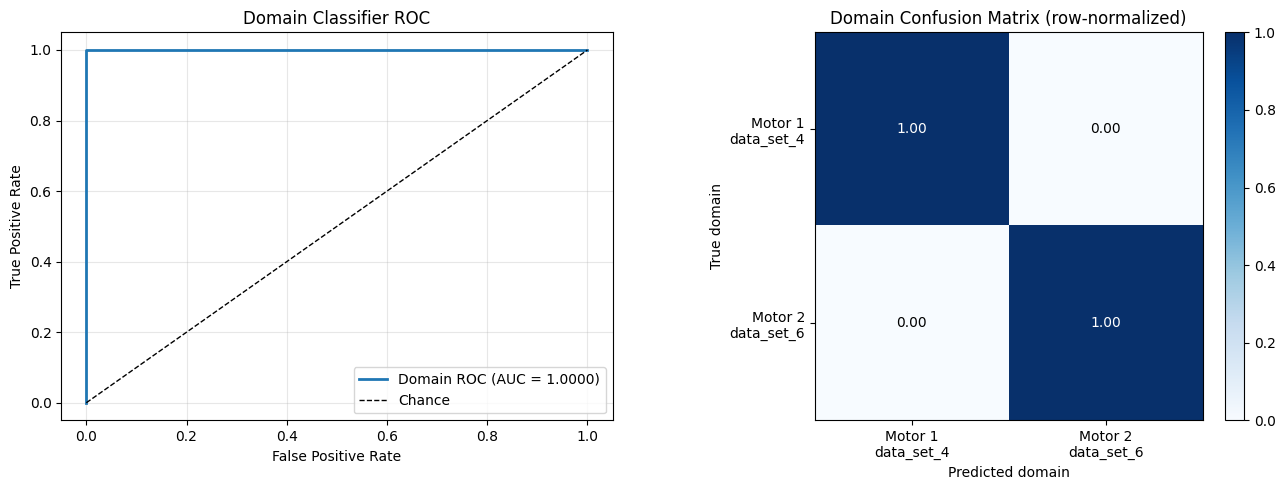

Interpretation:
  Strong domain shift (domains are highly separable).


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
axes[0].plot(fpr, tpr, color="tab:blue", linewidth=2, label=f"Domain ROC (AUC = {domain_auc:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
axes[0].set_title("Domain Classifier ROC")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Normalized confusion matrix
cm_float = domain_cm.astype(float)
row_sum = cm_float.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_float, np.where(row_sum == 0, 1.0, row_sum))
im = axes[1].imshow(cm_norm, cmap="Blues", vmin=0.0, vmax=1.0)
axes[1].set_title("Domain Confusion Matrix (row-normalized)")
axes[1].set_xlabel("Predicted domain")
axes[1].set_ylabel("True domain")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Motor 1\ndata_set_4", "Motor 2\ndata_set_6"])
axes[1].set_yticklabels(["Motor 1\ndata_set_4", "Motor 2\ndata_set_6"])

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        val = cm_norm[i, j]
        txt_color = "white" if val > 0.5 else "black"
        axes[1].text(j, i, f"{val:.2f}", ha="center", va="center", color=txt_color)

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

if domain_auc < 0.60:
    interpretation = "Low detectable domain shift (domains are hard to separate)."
elif domain_auc < 0.80:
    interpretation = "Moderate detectable domain shift."
else:
    interpretation = "Strong domain shift (domains are highly separable)."

print("Interpretation:")
print(f"  {interpretation}")

In [14]:
domain_diagnostic = {
    "domain_auc": float(domain_auc),
    "domain_accuracy": float(domain_accuracy),
    "fpr": fpr,
    "tpr": tpr,
    "thresholds": thresholds,
    "domain_cm": domain_cm,
    "feature_names": feature_names,
    "train_size": int(X_train.shape[0]),
    "val_size": int(X_val.shape[0]),
}

print("Saved diagnostic artifacts in variable: domain_diagnostic")
print(f"AUC={domain_diagnostic['domain_auc']:.4f}, accuracy={domain_diagnostic['domain_accuracy']:.4f}")

Saved diagnostic artifacts in variable: domain_diagnostic
AUC=1.0000, accuracy=0.9994
